In [1]:
import os
import pickle

# isort: off
import xarray as xr
import pint_xarray
import cf_xarray.units
# isort: on

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.figure import Figure

from utils import (
    PLASTIC_SIZES,
    PLASTIC_SOURCES,
    PROCESSED_DIR,
    RESULTS_DIR,
    apply_scales,
    clean_styler,
    combine_land_sources,
    fit_scales,
    load_observations,
    spatial_integrate,
)

# Overwrite outputs
OVERWRITE = True

# Initial guess for fitting scaling factors
SCALE_INITS = {
    # These values are taken from Fu et al. (2023)'s optimization code
    # See https://doi.org/10.17632/52knh3btb3.1 (optimizer/inv_observation4.m)
    "alt": xr.DataArray(
        [
            [0, 0, 0, 0, 0, 2.2],
            [0, 0, 0, 0, 0, 1.5],
            [0, 0, 0, 0, 0, 12],
            [0, 0, 0, 0, 0, 15],
            [0, 0, 0, 0, 0, 9.5],
        ],
        coords={
            "source": xr.DataArray(
                PLASTIC_SOURCES,
                dims="source",
                attrs={"description": "Emissions source"},
            ),
            "size": xr.DataArray(
                PLASTIC_SIZES,
                dims="size",
                attrs={"description": "Aerodynamic diameter", "units": "µm"},
            ),
        },
    ),
    # Set each source's scaling factor to 1
    "main": xr.DataArray(
        [1, 1, 1, 1, 1],
        coords={
            "source": xr.DataArray(
                PLASTIC_SOURCES,
                dims="source",
                attrs={"description": "Emissions source"},
            )
        },
    ),
}


def constrain_or_load_final(
    out_name: str, dataset: xr.Dataset, scales: xr.Dataset, overwrite: bool = False
) -> xr.Dataset:
    """Apply scales, combine terrestrial sources, and save"""

    out_path = os.path.join(RESULTS_DIR, out_name)
    if os.path.exists(out_path) and not overwrite:
        print(f"File exists: {out_path}")
        return xr.open_dataset(out_path)

    scaled = apply_scales(dataset=dataset, scales=scales)
    final = combine_land_sources(scaled)

    final.to_netcdf(out_path)
    print(f"-> {out_path}")

    # Load with data chunks for consistency
    return final


def fit_or_load_scales(
    out_name: str,
    sim: xr.Dataset,
    obs: dict[str, xr.Dataset],
    init: xr.DataArray,
    out_dir: str = RESULTS_DIR,
    overwrite: bool = False,
    tol: float = 1e-6,
    maxiter: int = 30000,
    **kwargs,
) -> tuple[xr.DataArray, dict]:
    """Fit and save scaling factors or load from disk"""

    trace_name = out_name.replace("scales_", "trace_").replace(".nc", ".pkl")
    out_path = os.path.join(out_dir, out_name)
    trace_path = os.path.join(out_dir, trace_name)
    if os.path.exists(out_path) and not overwrite:
        print(f"File exists: {out_path}")

        scales = xr.load_dataarray(out_path)
        with open(trace_path, "rb") as fp:
            trace = pickle.load(fp)
        return scales, trace

    # Define a callback to trace the scales as they are fitted
    trace = {"score": [], "scales": []}

    def trace_callback(intermediate_result) -> None:
        trace["score"].append(intermediate_result.fun.item())
        trace["scales"].append(intermediate_result.x.tolist())

    # Fit scaling factors
    scales = fit_scales(
        init=init,
        sim_conc=sim["concentration"].isel(lev=0, drop=True),
        sim_depo=sim["total_deposition"],
        obs_conc=obs["concentration"]["concentration"],
        obs_depo=obs["deposition"]["deposition"],
        tol=tol,
        maxiter=maxiter,
        callback=trace_callback,
        **kwargs,
    )

    # Describe and label
    scales.attrs["description"] = " ".join(
        [
            f"Scaling factors for {sim.label} simulation",
            f"based on {obs['concentration'].label} observations",
        ]
    )
    label = "_".join([sim.label, obs["concentration"].label])
    scales.attrs["label"] = label

    # Save scales
    scales.to_netcdf(out_path)
    print(f"-> {out_path}")

    # Save fitting trace
    with open(trace_path, "wb") as fp:
        pickle.dump(trace, fp, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"-> {trace_path}")

    return scales, trace


def plot_fit_trace(trace: dict, sim: xr.Dataset) -> Figure:
    """Plot the scale fitting trace"""

    # Compute scaled emissions for each iteration
    emis_unscaled = spatial_integrate(sim, varname="emission")
    n_iter = len(trace["scales"])
    coords = {"Iteration": range(n_iter)} | {
        k: emis_unscaled.coords[k] for k in emis_unscaled.dims
    }
    scale_trace = xr.DataArray(
        np.asarray(trace["scales"]).reshape([n_iter] + [x for x in emis_unscaled.shape]),
        coords=coords,
        dims=coords.keys(),
    )
    emis_trace = (scale_trace * emis_unscaled).assign_attrs(emis_unscaled.attrs)
    if "size" in emis_trace.dims:
        emis_trace = emis_trace.sum(dim="size", keep_attrs=True)

    fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(6, 6))

    # Plot score over fitting iterations
    ax1.plot(np.asarray(trace["score"]), color="#a6611a")
    ax1.set_ylabel("Score")

    palette = {
        "ocean": "#386cb0",
        "mmpw": "grey",
        "agricultural": "#7fc97f",
        "residential": "#fdc086",
        "road": "black",
        "land": "#7fc97f",
    }
    for src in emis_trace["source"].values:
        emis_trace.sel(source=src).plot.line(
            ax=ax2, x="Iteration", label=src, color=palette[src]
        )
    ax2.set_ylabel(f"Emissions [{emis_trace.units}]")
    ax2.set_title("")
    ax2.legend(loc="upper right")

    return fig


Introduction
------------

This notebook constrains simulated atmospheric micropastics to match size-harmonized observations. We use the same approach as @Fu2023: compute scaling factors that minimized the squared difference between log-transformed simulated atmospheric microplastic concentration and deposition and log-transformed observations.

Constrain *main* simulation
---------------------------

The *main* simulation is based on the configuration of @Fu2023, with five atmospheric microplastic emissions sources (oceans, mismanaged plastic waste [MMPW], agriculture, residences, roads) and six spherical tracers (diameters 0.3, 2.5, 7, 15, 35, 70 µm).

The inital emissions factors were set so that each source emits approximately 1 Gg/yr distributed over the six tracers following a power law particle number size distribution with parameter $\alpha$ = 2.8 (log-log slope of -2.8). This is the median slope for atmospheric microplastic fragments in MPsizeBase [@Sonke2025]. See [size-harmonize-obs.ipynb](size-harmonize-obs.ipynb) for calculation of the median $\alpha$ and [compute-emission-factors.ipynb](compute-emission-factors.ipynb) for calculation of the emission factors and size distribution factors used in the *main* simulation.

We use size-harmonized observations of atmospheric microplastic concentration and deposition to constrain the simulation. See [size-harmonize-obs.ipynb](size-harmonize-obs.ipynb) for details of the size-harmonization. The original (unharmonized) observations were collected from the literature by @Fu2023.

We compute a single scaling factor for each source and apply it to all tracer sizes. This ensures that constrained emissions have a realistic particle size distribution. The initial value of each scale is set to 1.

In [2]:
# Load simulation outputs and combine all sizes
sim_path = os.path.join(RESULTS_DIR, "sim_main.nc")
sim_main = xr.open_dataset(sim_path, chunks="auto")
sim_main_total = sim_main.sum(dim="size", keep_attrs=True)

# Load observations
obs_main = {
    "concentration": load_observations("obs_size-harmonized_concentration.csv"),
    "deposition": load_observations("obs_size-harmonized_deposition.csv"),
}

# Define initial guess for scaling factors
init_main = SCALE_INITS["main"]
init_main.to_dataframe("Initial scales: main")

,Initial scales: main
source,
ocean,1
mmpw,1
agricultural,1
residential,1
road,1


In [3]:
# Fit scales
scales_main, trace_main = fit_or_load_scales(
    out_name="scales_main.nc",
    init=init_main,
    sim=sim_main_total,
    obs=obs_main,
    overwrite=OVERWRITE,
)

Optimization terminated successfully.
         Current function value: 81.508637
         Iterations: 578
         Function evaluations: 1023
-> results/scales_main.nc
-> results/trace_main.pkl


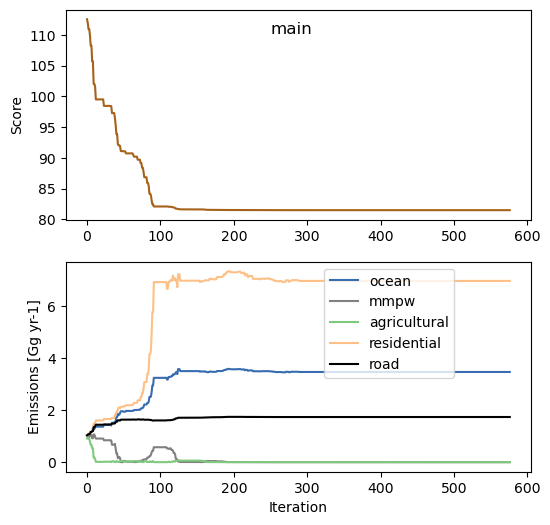

In [4]:
# Plot trace
fig_main = plot_fit_trace(trace_main, sim_main_total)
legend = fig_main.axes[1].get_legend()
legend.set_bbox_to_anchor((0.85, 1))
_ = fig_main.suptitle("main", y=0.86)

In [5]:
# Apply scaling factors to the size-resolved outputs and combine terrestrial sources
final_main = constrain_or_load_final(
    out_name="sim_main_constrained.nc",
    dataset=sim_main,
    scales=scales_main,
    overwrite=OVERWRITE,
)

-> results/sim_main_constrained.nc


In [6]:
# Compute scaled emissions
emis_main = spatial_integrate(final_main, varname="emission", sum_dims="size")

clean_styler(
    emis_main.to_dataframe(f"Emission [{emis_main.units}]: main")
    .sort_index()
    .style.format(precision=2)
)

,Emission [Gg yr-1]: main
source,
land,8.70
ocean,3.46


Constrain *alternate* simulation
--------------------------------

The *alternate* simulation uses the same configuration as @Fu2023.

The inital emissions factors are set to the values used by @Fu2023, with each source's emissions factor applied to all tracer sizes.

We use the (unharmonized) observations collected from the literature by @Fu2023, updated to ensure consistency with the study-reported locations and microplastic counts. See [prep-fu2023-obs.ipynb](prep-fu2023-obs.ipynb) for details.

We constrain the simulation by computing scaling factors for each tracer and source (6 tracers * 5 sources = 30 scales). In other words, we use the unharmonized observations to set both the total mass emitted from each source and the source-specific particle size distribution of the emissions. We use the same initial values for the scaling factors as @Fu2023, who say they chose the values to give similar emissions as @Brahney2021. The initial factors assume only large particles are emitted.

In [7]:
# Load simulation outputs
sim_path = os.path.join(RESULTS_DIR, "sim_alt.nc")
sim_alt = xr.open_dataset(sim_path, chunks="auto")

# Load observations
obs_alt = {
    "concentration": load_observations(
        "obs_revised_concentration.csv", data_dir=PROCESSED_DIR
    ),
    "deposition": load_observations("obs_revised_deposition.csv", data_dir=PROCESSED_DIR),
}

# Define initial guess for scaling factors
init_alt = SCALE_INITS["alt"]
init_alt.to_dataframe("Initial scales: alternate").unstack("size")

Initial scales: alternate                          
size                              0.3  2.5  7.0  15.0 35.0  70.0
source                                                          
ocean                              0.0  0.0  0.0  0.0  0.0   2.2
mmpw                               0.0  0.0  0.0  0.0  0.0   1.5
agricultural                       0.0  0.0  0.0  0.0  0.0  12.0
residential                        0.0  0.0  0.0  0.0  0.0  15.0
road                               0.0  0.0  0.0  0.0  0.0   9.5

In [8]:
# Fit scales
scales_alt, trace_alt = fit_or_load_scales(
    out_name="scales_alt.nc",
    init=init_alt,
    sim=sim_alt,
    obs=obs_alt,
    overwrite=OVERWRITE,
)

Optimization terminated successfully.
         Current function value: 75.028420
         Iterations: 13464
         Function evaluations: 17590
-> results/scales_alt.nc
-> results/trace_alt.pkl


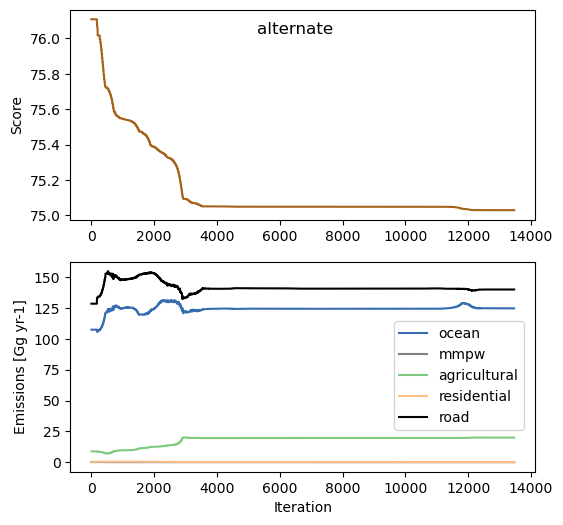

In [9]:
# Plot trace
fig_alt = plot_fit_trace(trace=trace_alt, sim=sim_alt)
legend = fig_alt.axes[1].get_legend()
legend.set_bbox_to_anchor((0.99, 0.75))
_ = fig_alt.suptitle("alternate", y=0.86)

In [10]:
# Apply scaling factors and combine terrestrial sources
final_alt = constrain_or_load_final(
    out_name="sim_alt_constrained.nc", dataset=sim_alt, scales=scales_alt
)

-> results/sim_alt_constrained.nc


In [11]:
# Compute scaled emissions
emis_alt = spatial_integrate(final_alt, varname="emission")

clean_styler(
    emis_alt.sum(dim="size")
    .to_dataframe(f"Scaled emissions: alternate [{emis_alt.units}]")
    .sort_index()
    .style.format(precision=2)
)

,Scaled emissions: alternate [Gg yr-1]
source,
land,159.93
ocean,124.71
